<a href="https://colab.research.google.com/github/kannanrk28/Capstone_Masai_FinalProject_Kannan/blob/main/part1/Part1_DataPreparationProcess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part 1 — Data Acquisition, Cleaning, and Exploratory Analysis

In [88]:
import pandas as pd

# Read Dataset from Github repo
URL = "https://raw.githubusercontent.com/kannanrk28/Capstone_Masai_FinalProject_Kannan/main/dataset/tmdb-movies.csv"
df_movie = pd.read_csv(URL)

#Printing laptop data shape and data types
print(df_movie.shape)
print(df_movie.dtypes)
print(df_movie.head(5))

(10866, 21)
id                        int64
imdb_id                  object
popularity              float64
budget                    int64
revenue                   int64
original_title           object
cast                     object
homepage                 object
director                 object
tagline                  object
keywords                 object
overview                 object
runtime                   int64
genres                   object
production_companies     object
release_date             object
vote_count                int64
vote_average            float64
release_year              int64
budget_adj              float64
revenue_adj             float64
dtype: object
       id    imdb_id  popularity     budget     revenue  \
0  135397  tt0369610   32.985763  150000000  1513528810   
1   76341  tt1392190   28.419936  150000000   378436354   
2  262500  tt2908446   13.112507  110000000   295238201   
3  140607  tt2488496   11.173104  200000000  2068178225   
4  1682

In [89]:
#Finding null count
null_count=df_movie.isnull().sum()
print(f'Null Count:{null_count}')

Null Count:id                         0
imdb_id                   10
popularity                 0
budget                     0
revenue                    0
original_title             0
cast                      76
homepage                7930
director                  44
tagline                 2824
keywords                1493
overview                   4
runtime                    0
genres                    23
production_companies    1030
release_date               0
vote_count                 0
vote_average               0
release_year               0
budget_adj                 0
revenue_adj                0
dtype: int64


In [90]:
#Finding null percentage
null_percentage=((df_movie.isnull().sum()/df_movie.shape[0])*100)
print(f'Null Percentage:{null_percentage}')

Null Percentage:id                       0.000000
imdb_id                  0.092030
popularity               0.000000
budget                   0.000000
revenue                  0.000000
original_title           0.000000
cast                     0.699429
homepage                72.979937
director                 0.404933
tagline                 25.989324
keywords                13.740107
overview                 0.036812
runtime                  0.000000
genres                   0.211669
production_companies     9.479109
release_date             0.000000
vote_count               0.000000
vote_average             0.000000
release_year             0.000000
budget_adj               0.000000
revenue_adj              0.000000
dtype: float64


In [91]:
#Finding columns which has null values greater than 20%
col_with_null_values=null_percentage[null_percentage>20]
if len(col_with_null_values) == 0:
    print('No columns have null values greater than 20%.')
else:
    print(f'Columns with null values greater than 20%:{col_with_null_values}')

Columns with null values greater than 20%:homepage    72.979937
tagline     25.989324
dtype: float64


In [92]:
# Convert binary columns to boolean
df_clean=df_movie.copy()

# Find categorical columns (release_date will no longer be included)
categorical_columns = df_clean.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns.tolist())

# Find boolean columns
boolean_columns = df_clean.select_dtypes(include=['bool']).columns

print("\nBoolean Columns:")
print(boolean_columns.tolist())
print(df_clean.dtypes)

Categorical Columns:
['imdb_id', 'original_title', 'cast', 'homepage', 'director', 'tagline', 'keywords', 'overview', 'genres', 'production_companies', 'release_date']

Boolean Columns:
[]
id                        int64
imdb_id                  object
popularity              float64
budget                    int64
revenue                   int64
original_title           object
cast                     object
homepage                 object
director                 object
tagline                  object
keywords                 object
overview                 object
runtime                   int64
genres                   object
production_companies     object
release_date             object
vote_count                int64
vote_average            float64
release_year              int64
budget_adj              float64
revenue_adj             float64
dtype: object


In [93]:
# Select numeric columns

numeric_columns = df_clean.select_dtypes(include=['int64', 'float64']).columns
counter =1
# Impute missing values using median
for col in numeric_columns:
    null_percentage = (df_clean[col].isnull().sum() / len(df_clean)) * 100

    if 0 < null_percentage < 20:
        counter= counter +1
        median_value = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_value)

        print(f"Filled missing values in '{col}' using median: {median_value}")

if(counter == 1) :
  print(f"This data set does not contain any null values for the data type Integer or Float")

This data set does not contain any null values for the data type Integer or Float


In [94]:
#Finding duplicates and removing it
total_rows = df_clean.shape[0]
print(f"Total rows in the Movies DataFrame: {total_rows}")
duplicates_count=df_clean.duplicated().sum()
print(f"Total duplicate rows in the Movies DataFrame: {duplicates_count}")
df_clean=df_clean.drop_duplicates()
print(f"Total rows after dropping duplicates: {df_clean.shape[0]}")
print(f'Initial Null Percentage:{null_percentage}')
null_percentage_df_clean = (df_clean[col].isnull().sum() / df_clean.shape[0]) * 100
print(f'Null Percentage after dropping duplicates:{null_percentage_df_clean}')
df_clean.shape

Total rows in the Movies DataFrame: 10866
Total duplicate rows in the Movies DataFrame: 1
Total rows after dropping duplicates: 10865
Initial Null Percentage:0.0
Null Percentage after dropping duplicates:0.0


(10865, 21)

In [95]:
# 4. Data type correction:
# Convert release_date to datetime
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')

# Memory usage before data type conversion
memory_before = df_clean.memory_usage(deep=True).sum()
print(f"Memory usage before conversion: {memory_before} bytes")

# Check original data types
print("\nData types before conversion:")
# print(df_clean.dtypes)

# Convert repetitive string columns to category
category_cols = ['genres', 'director']

for col in category_cols:
    df_clean[col] = df_clean[col].astype('category')

# Memory after conversion
memory_after = df_clean.memory_usage(deep=True).sum()

print(f"Memory after : {memory_after:,} bytes")
print(f"Memory saved : {memory_before - memory_after:,} bytes")
print(f"Justification:\nConverting genres and director columns to category type did not show any change in memory optimization, that's because this particular dataset doesn't have many low-cardinality object columns.")

/tmp/ipykernel_3170/3155861536.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')


Memory usage before conversion: 12574642 bytes

Data types before conversion:
Memory after : 11,879,316 bytes
Memory saved : 695,326 bytes
Justification:
Converting genres and director columns to category type did not show any change in memory optimization, that's because this particular dataset doesn't have many low-cardinality object columns.


In [96]:
# 5.Descriptive statistics and skewness:

# Select numeric columns
numeric_columns = df_clean.select_dtypes(include=['int64', 'float64']).columns

# Descriptive statistics
print("Descriptive Statistics:")
print(df_clean[numeric_columns].describe())

# Calculate skewness for each numeric column
skewness = df_clean[numeric_columns].skew()

print("\nSkewness of Numeric Columns:")
print(skewness.sort_values(key=abs, ascending=False))

# Find the column with the highest absolute skewness
highest_skew_col = skewness.abs().idxmax()
highest_skew_value = skewness[highest_skew_col]

print(f"\nColumn with highest absolute skewness: {highest_skew_col}")
print(f"Skewness value: {highest_skew_value:.3f}")

Descriptive Statistics:
                  id    popularity        budget       revenue       runtime  \
count   10865.000000  10865.000000  1.086500e+04  1.086500e+04  10865.000000   
mean    66066.374413      0.646446  1.462429e+07  3.982690e+07    102.071790   
std     92134.091971      1.000231  3.091428e+07  1.170083e+08     31.382701   
min         5.000000      0.000065  0.000000e+00  0.000000e+00      0.000000   
25%     10596.000000      0.207575  0.000000e+00  0.000000e+00     90.000000   
50%     20662.000000      0.383831  0.000000e+00  0.000000e+00     99.000000   
75%     75612.000000      0.713857  1.500000e+07  2.400000e+07    111.000000   
max    417859.000000     32.985763  4.250000e+08  2.781506e+09    900.000000   

         vote_count  vote_average  release_year    budget_adj   revenue_adj  
count  10865.000000  10865.000000  10865.000000  1.086500e+04  1.086500e+04  
mean     217.399632      5.975012   2001.321859  1.754989e+07  5.136900e+07  
std      575.644627  

In [97]:
# 6. Outlier detection with IQR:

# Numeric columns to analyze
columns = ['popularity', 'revenue']

for col in columns:
    # Calculate Q1, Q3 and IQR
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    # Calculate lower and upper bounds
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    # Count outliers
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]

    print(f"\nColumn: {col}")
    print(f"Q1           : {Q1:.2f}")
    print(f"Q3           : {Q3:.2f}")
    print(f"IQR          : {IQR:.2f}")
    print(f"Lower Bound  : {lower_bound:.2f}")
    print(f"Upper Bound  : {upper_bound:.2f}")
    print(f"Outliers     : {len(outliers)}")


Column: popularity
Q1           : 0.21
Q3           : 0.71
IQR          : 0.51
Lower Bound  : -0.55
Upper Bound  : 1.47
Outliers     : 946

Column: revenue
Q1           : 0.00
Q3           : 24000000.00
IQR          : 24000000.00
Lower Bound  : -36000000.00
Upper Bound  : 60000000.00
Outliers     : 1736


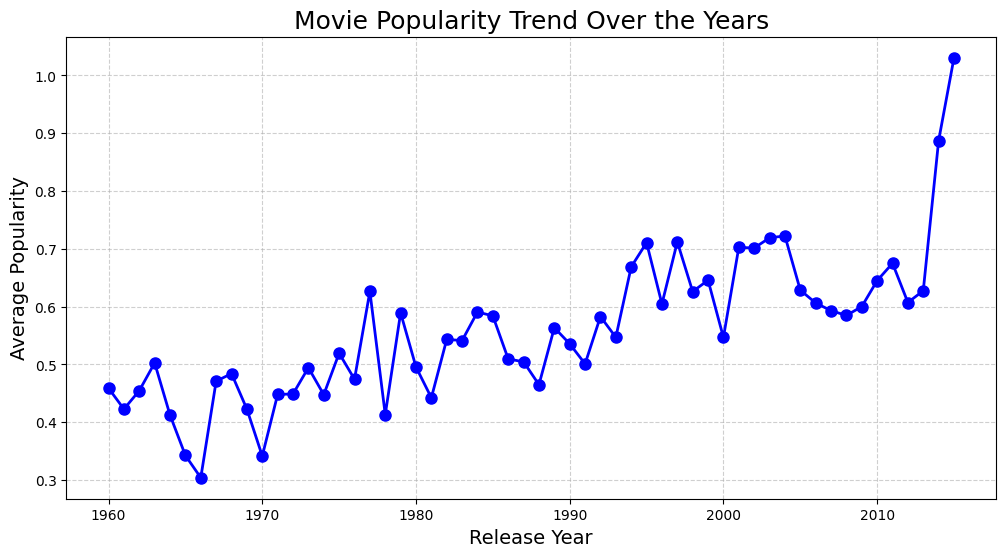

In [98]:
# 7.Visualization - Line chart
import matplotlib.pyplot as plt

# Calculate average popularity by release year
popularity_by_year = (
    df_clean.groupby('release_year')['popularity']
    .mean()
    .reset_index()
)

# Create the line plot
plt.figure(figsize=(12, 6))

plt.plot(
    popularity_by_year['release_year'],
    popularity_by_year['popularity'],
    marker='o',
    linestyle='-',
    linewidth=2,
    markersize=8,
    color='blue'
)

# Add title and labels
plt.title('Movie Popularity Trend Over the Years', fontsize=18)
plt.xlabel('Release Year', fontsize=14)
plt.ylabel('Average Popularity', fontsize=14)

# Add grid
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()

/tmp/ipykernel_3170/1281901362.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby('genres')['popularity']


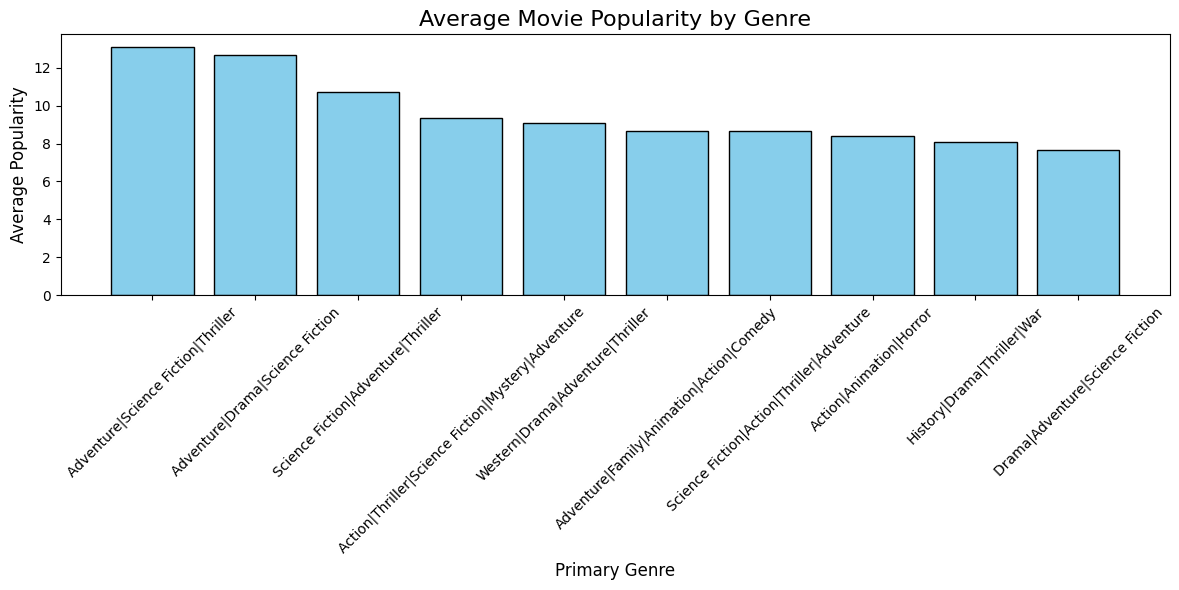

In [99]:
# 7.Visualization - Bar chart
import matplotlib.pyplot as plt

# # Extract the primary genre (first genre listed)
# df_clean['primary_genre'] = df_clean['genres'].str.split('|').str[0]

# Calculate the average popularity for each genre
genre_popularity = (
    df_clean.groupby('genres')['popularity']
    .mean()
    .sort_values(ascending=False)
    .head(10)   # Show only top 10 combinations
)

# Create bar chart
plt.figure(figsize=(12, 6))

plt.bar(
    genre_popularity.index,
    genre_popularity.values,
    color='skyblue',
    edgecolor='black'
)

# Add title and labels
plt.title('Average Movie Popularity by Genre', fontsize=16)
plt.xlabel('Primary Genre', fontsize=12)
plt.ylabel('Average Popularity', fontsize=12)

# Rotate x-axis labels
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

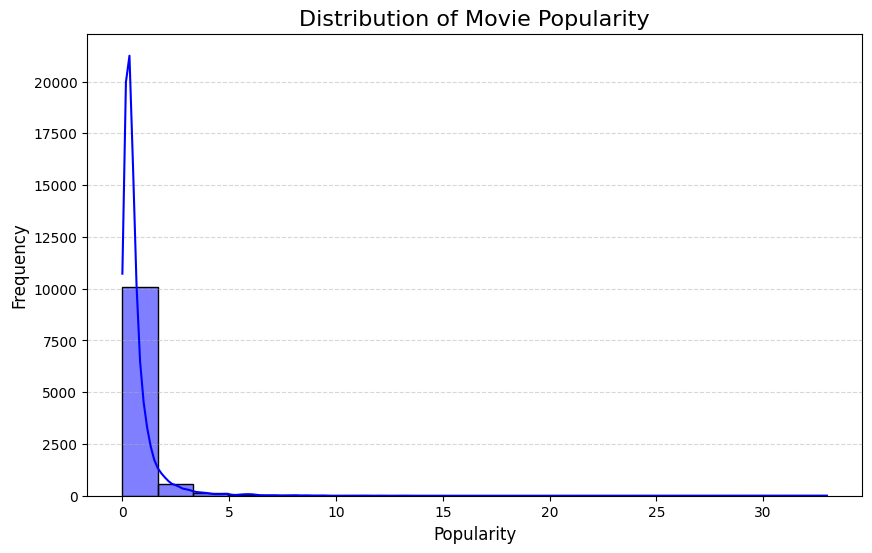

In [100]:
# Visualization - Histogram
import matplotlib.pyplot as plt
import seaborn as sns

# Create histogram for the most skewed numeric column
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x='popularity',
    bins=20,
    color='blue',
    edgecolor='black',
    kde=True
)

# Add title and labels
plt.title('Distribution of Movie Popularity', fontsize=16)
plt.xlabel('Popularity', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

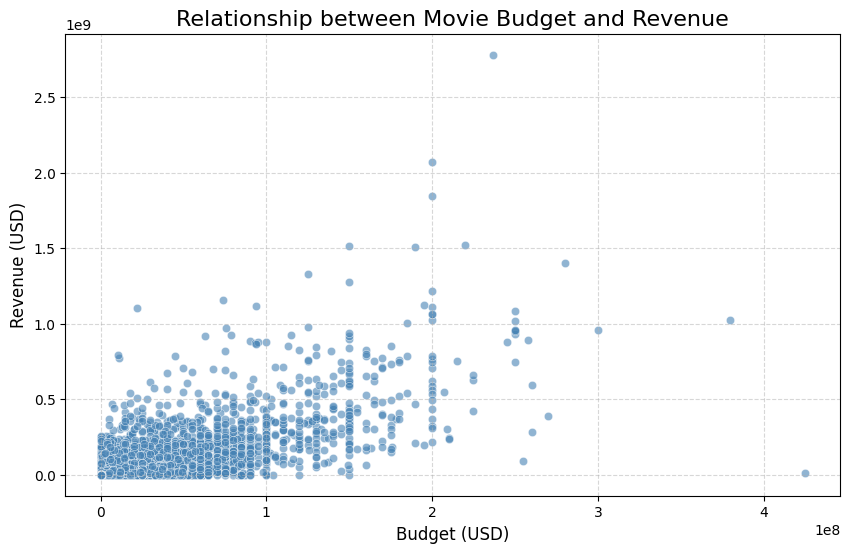

In [101]:
# 7.Visualization - Scatter Plot

import matplotlib.pyplot as plt
import seaborn as sns

# Create scatter plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x='budget',
    y='revenue',
    color='steelblue',
    alpha=0.6
)

# Add title and labels
plt.title('Relationship between Movie Budget and Revenue', fontsize=16)
plt.xlabel('Budget (USD)', fontsize=12)
plt.ylabel('Revenue (USD)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

/tmp/ipykernel_3170/660393616.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


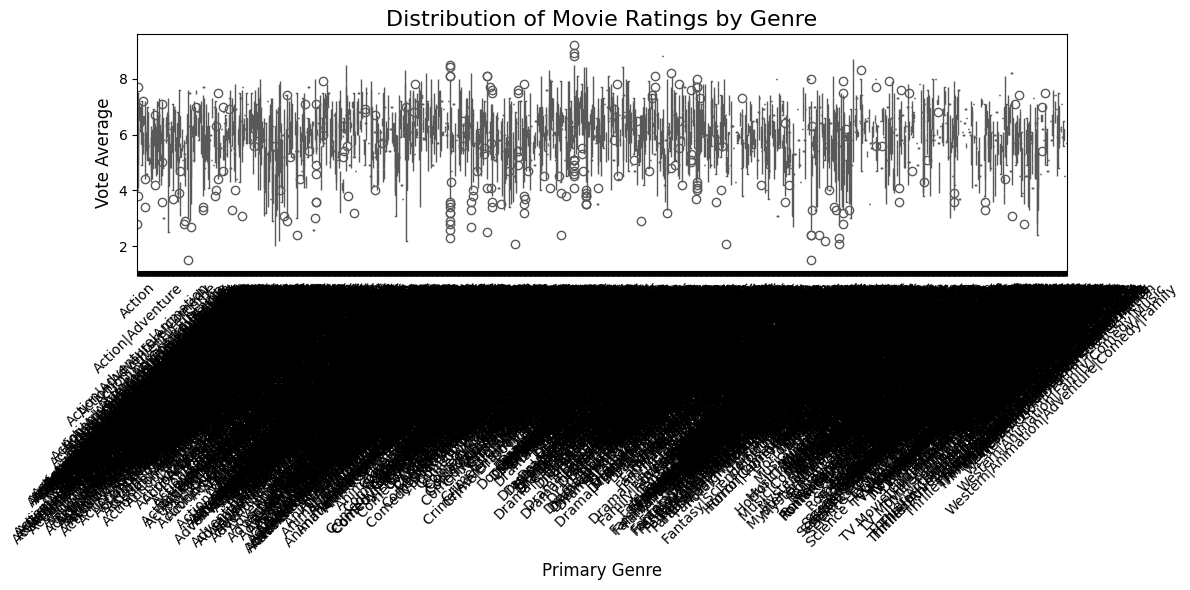

In [102]:
# 7.Visualization - BoxPlot

import matplotlib.pyplot as plt
import seaborn as sns

# Extract the primary genre (first genre listed)
# df_clean['genres'] = df_clean['genres'].str.split('|').str[0]

# Create box plot
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_clean,
    x='genres',
    y='vote_average',
    palette='Set2'
)

# Add title and labels
plt.title('Distribution of Movie Ratings by Genre', fontsize=16)
plt.xlabel('Primary Genre', fontsize=12)
plt.ylabel('Vote Average', fontsize=12)

# Rotate x-axis labels
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

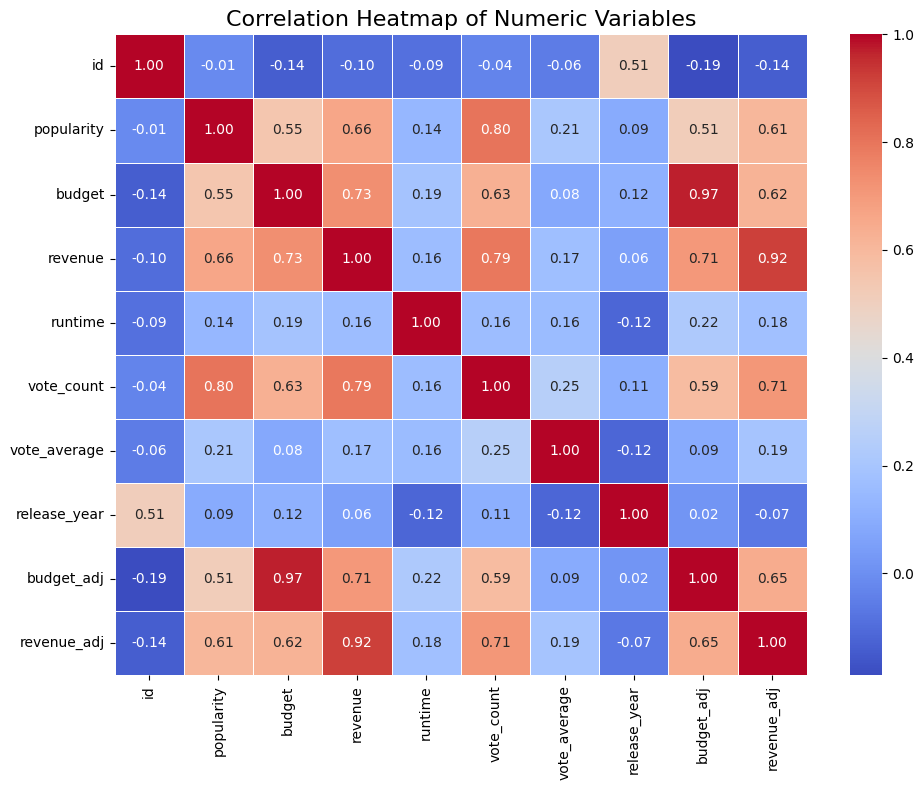

Highest Absolute Correlation:
budget  budget_adj    0.968963
dtype: float64


In [103]:
# 8.Correlation Heat Map
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select only numeric columns
numeric_df = df_clean.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Variables", fontsize=16)

plt.tight_layout()
plt.show()

# Find the highest absolute correlation (excluding self-correlation)
corr_abs = corr_matrix.abs()
np.fill_diagonal(corr_abs.values, 0)

highest_corr = corr_abs.unstack().sort_values(ascending=False).drop_duplicates()

print("Highest Absolute Correlation:")
print(highest_corr.head(1))

In [104]:
# 9. Imputation Strategic Comparison

# Two most skewed numeric columns
skewed_columns = ['popularity', 'revenue']

for col in skewed_columns:
    mean_value = df_clean[col].mean()
    median_value = df_clean[col].median()

    print(f"\nColumn: {col}")
    print(f"Mean   : {mean_value:.2f}")
    print(f"Median : {median_value:.2f}")

    # Impute missing values using median
    df_clean[col] = df_clean[col].fillna(median_value)

# Verify that no missing values remain
print("\nMissing Values After Imputation:")
print(df_clean[skewed_columns].isnull().sum())


Column: popularity
Mean   : 0.65
Median : 0.38

Column: revenue
Mean   : 39826896.08
Median : 0.00

Missing Values After Imputation:
popularity    0
revenue       0
dtype: int64


In [105]:
# 9. Spearman Rank Correlation
import pandas as pd
import numpy as np

# Select only numeric columns
numeric_df = df_clean.select_dtypes(include=['int64', 'float64'])

# Pearson correlation matrix
pearson_corr = numeric_df.corr(method='pearson')

# Spearman correlation matrix
spearman_corr = numeric_df.corr(method='spearman')

# Print both matrices
print("Pearson Correlation Matrix")
print(pearson_corr)

print("\nSpearman Correlation Matrix")
print(spearman_corr)

# Difference between Spearman and Pearson
corr_difference = (spearman_corr - pearson_corr).abs()

# Remove duplicate pairs and self-correlations
mask = np.triu(np.ones(corr_difference.shape), k=1).astype(bool)

difference_table = (
    corr_difference.where(mask)
    .stack()
    .reset_index()
)

difference_table.columns = ['Variable 1', 'Variable 2', '|Spearman - Pearson|']

# Sort by largest difference
difference_table = difference_table.sort_values(
    by='|Spearman - Pearson|',
    ascending=False
)

print("\nDifference Table")
print(difference_table)

print("\nTop 3 Variable Pairs")
print(difference_table.head(3))

Pearson Correlation Matrix
                    id  popularity    budget   revenue   runtime  vote_count  \
id            1.000000   -0.014351 -0.141341 -0.099235 -0.088368   -0.035555   
popularity   -0.014351    1.000000  0.545481  0.663360  0.139032    0.800828   
budget       -0.141341    0.545481  1.000000  0.734928  0.191300    0.632719   
revenue      -0.099235    0.663360  0.734928  1.000000  0.162830    0.791174   
runtime      -0.088368    0.139032  0.191300  0.162830  1.000000    0.163273   
vote_count   -0.035555    0.800828  0.632719  0.791174  0.163273    1.000000   
vote_average -0.058391    0.209517  0.081067  0.172541  0.156813    0.253818   
release_year  0.511393    0.089806  0.115904  0.057070 -0.117187    0.107962   
budget_adj   -0.189008    0.513555  0.968963  0.706446  0.221127    0.587062   
revenue_adj  -0.138487    0.609085  0.622531  0.919109  0.175668    0.707941   

              vote_average  release_year  budget_adj  revenue_adj  
id               -0.0583

In [106]:
# 9 Grouped Aggregation
import pandas as pd

# Create primary genre from the genres column
# df_clean['primary_genre'] = df_clean['genres'].str.split('|').str[0]

# Group by primary genre and compute statistics
grouped_stats = (
    df_clean.groupby('genres')['popularity']
    .agg(['mean', 'std', 'count'])
    .sort_values(by='mean', ascending=False)
)

print(grouped_stats)

# Find the group with the highest mean
highest_mean_group = grouped_stats['mean'].idxmax()
highest_mean = grouped_stats['mean'].max()

# Find the group with the highest standard deviation
highest_std_group = grouped_stats['std'].idxmax()
highest_std = grouped_stats['std'].max()

# Find the lowest group mean
lowest_mean_group = grouped_stats['mean'].idxmin()
lowest_mean = grouped_stats['mean'].min()

# Calculate the ratio
ratio = highest_mean / lowest_mean

print("\nGroup with Highest Mean:")
print(f"{highest_mean_group} ({highest_mean:.2f})")

print("\nGroup with Highest Standard Deviation:")
print(f"{highest_std_group} ({highest_std:.2f})")

print(f"\nHighest Mean / Lowest Mean Ratio: {ratio:.2f}")

                                                        mean        std  count
genres                                                                        
Adventure|Science Fiction|Thriller                 13.112507        NaN      1
Adventure|Drama|Science Fiction                    12.699699  17.323317      2
Science Fiction|Adventure|Thriller                 10.739009        NaN      1
Action|Thriller|Science Fiction|Mystery|Adventure   9.363643        NaN      1
Western|Drama|Adventure|Thriller                    9.110700        NaN      1
...                                                      ...        ...    ...
Documentary|Drama|Foreign                           0.004590        NaN      1
Horror|Mystery|Thriller|Crime                       0.002381        NaN      1
Drama|Thriller|Science Fiction|Romance|Foreign      0.001983        NaN      1
Crime|Drama|History|Documentary                     0.001372        NaN      1
Mystery|Comedy|Drama                                

/tmp/ipykernel_3170/29640208.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean.groupby('genres')['popularity']


In [107]:
# 10. Save and verify Cleaned data

# Save the cleaned dataset to a CSV file
df_clean.to_csv('cleaned_data.csv', index=False)

print("Cleaned dataset saved successfully as 'cleaned_data.csv'.")

# Load the saved dataset to verify
df_verify = pd.read_csv('cleaned_data.csv')

# print(df_verify.head())
print(df_verify.shape)

Cleaned dataset saved successfully as 'cleaned_data.csv'.
(10865, 21)


In [108]:
print(df_movie.dtypes)
print("/n")
print(df_clean.dtypes)

id                        int64
imdb_id                  object
popularity              float64
budget                    int64
revenue                   int64
original_title           object
cast                     object
homepage                 object
director                 object
tagline                  object
keywords                 object
overview                 object
runtime                   int64
genres                   object
production_companies     object
release_date             object
vote_count                int64
vote_average            float64
release_year              int64
budget_adj              float64
revenue_adj             float64
dtype: object
/n
id                               int64
imdb_id                         object
popularity                     float64
budget                           int64
revenue                          int64
original_title                  object
cast                            object
homepage                        object